<img src="logo-UNSAM.png" style="float: right;" width="300" alt="Logo">

# <center>Análisis y Procesamiento de Señales</center>
<hr>

## <center>**TS5**: "Estimación espectral - Ancho de banda de señales reales"</center>

<br><br>

### <center>1er Cuatrimestre - 2026</center>
### <center>**Alumno:** D'Alesio Alejo</center>


<br>

En esta práctica vamos a realizar la Estimación Espectral de Potencia (PSD) de señales reales. El enunciado nos pide utilizar un método visto en clase. Voy a utilizar el método de Welch.

Inicialmente visualizamos las señales a analizar.

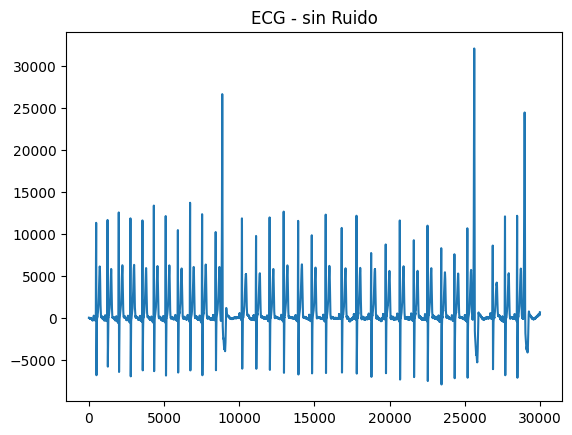

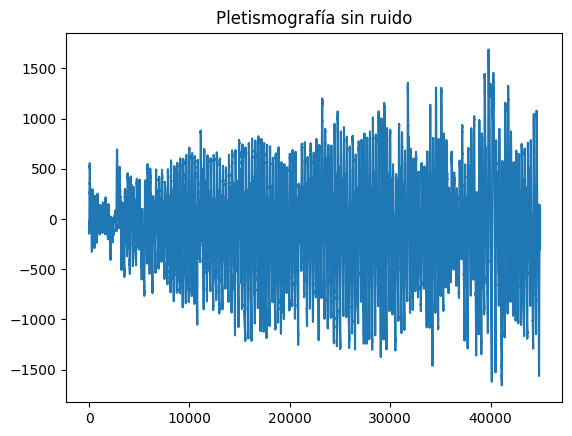

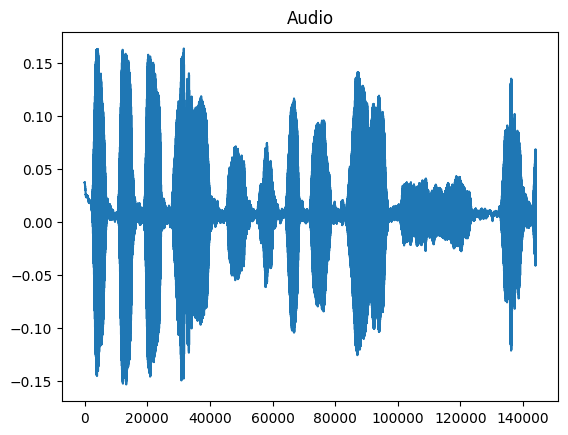

In [13]:
import numpy as np
from scipy import signal as sig

import matplotlib.pyplot as plt
   
import scipy.io as sio
from scipy.io.wavfile import write

##################
# Lectura de ECG #
##################

fs_ecg = 1000 # Hz

##################
## ECG sin ruido
##################

ecg_one_lead = np.load(r'pdstestbench/ecg_sin_ruido.npy')

plt.figure()
plt.plot(ecg_one_lead)
plt.title('ECG - sin Ruido')

####################################
# Lectura de pletismografía (PPG)  #
####################################

fs_ppg = 400 # Hz

##################
## PPG sin ruido
##################

ppg = np.load('pdstestbench/ppg_sin_ruido.npy')

plt.figure()
plt.plot(ppg)
plt.title('Pletismografía sin ruido')

#%%
####################
# Lectura de audio #
####################

fs_audio, wav_data = sio.wavfile.read('pdstestbench/la cucaracha.wav')

plt.figure()
plt.title('Audio')
plt.plot(wav_data)


Ahora aplico Welch a cada señal y grafico cada señal.

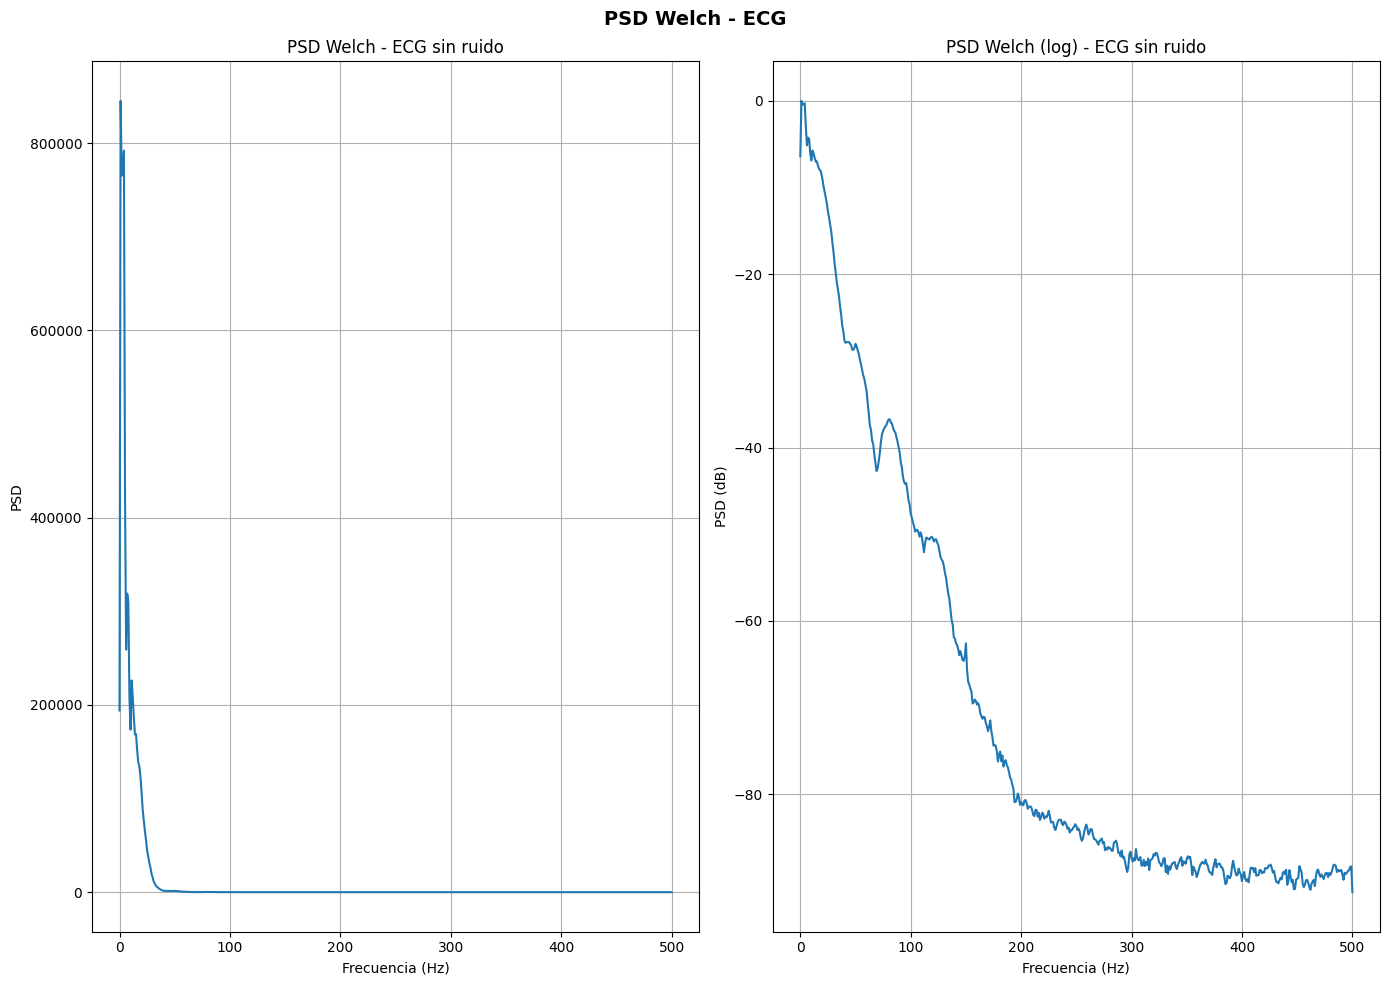

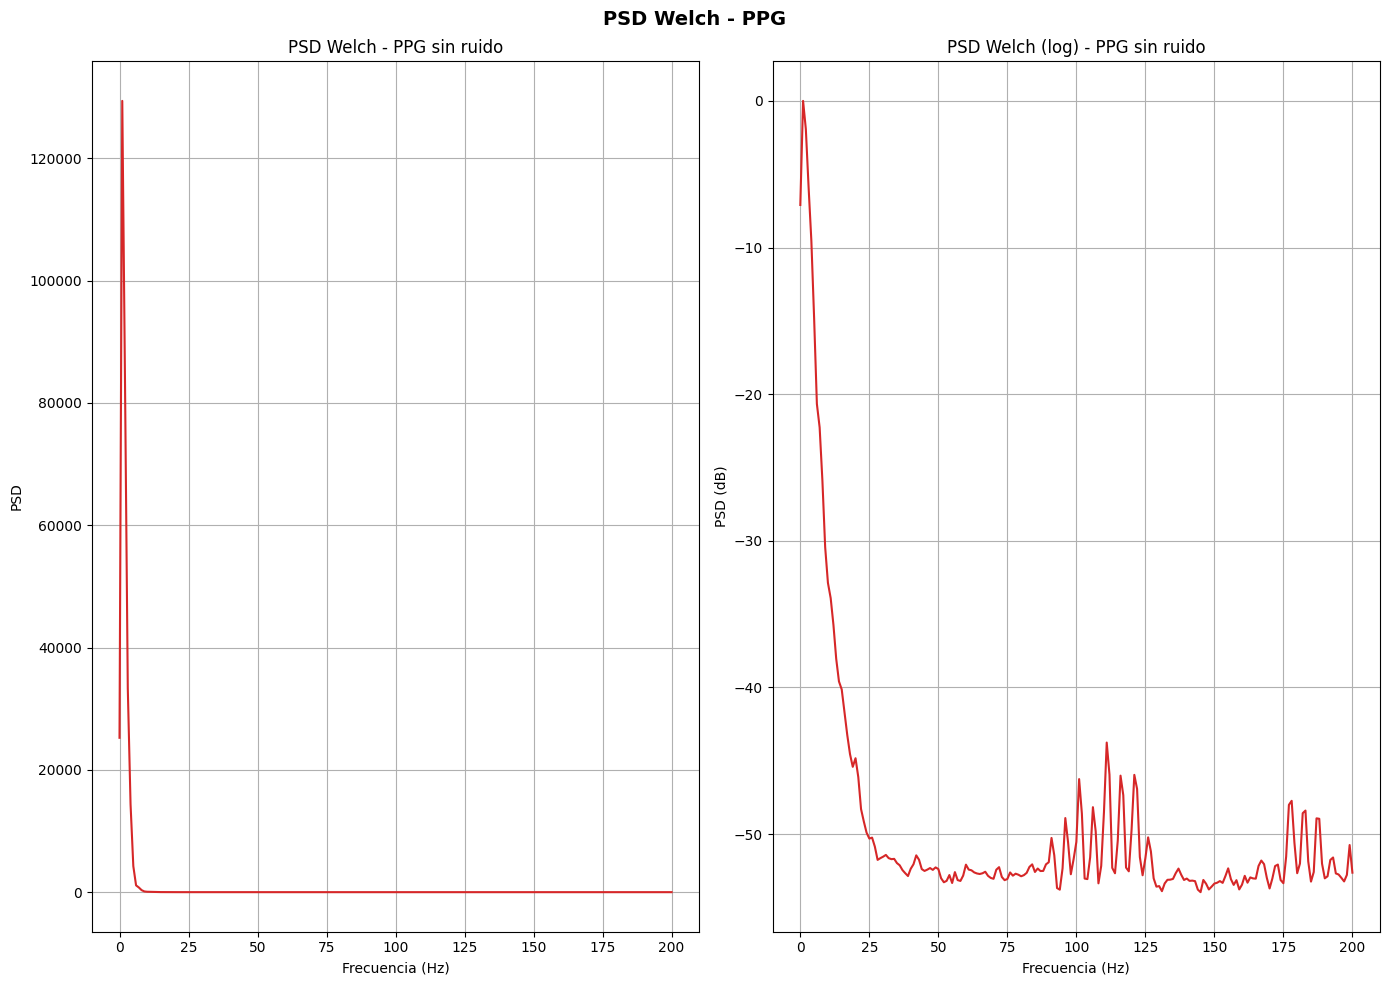

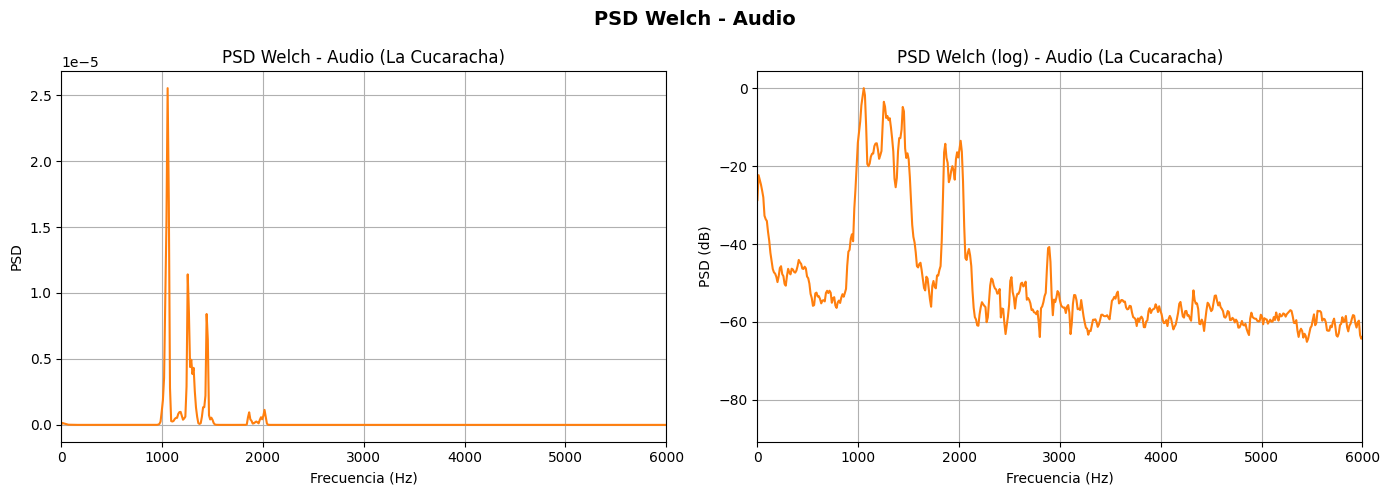

In [14]:
#%% ---- PSD --------
################
#----WELCH------
################
# 1) ECG 
#---- Sin Ruido--------

f_ECG, P_ECG = sig.welch(ecg_one_lead, fs_ecg, window='hann', nperseg=fs_ecg, noverlap=(fs_ecg/2), nfft=None, detrend='constant', return_onesided=True, scaling='density', axis=-1, average='mean')


# 2) PPG
#---- Sin Ruido --------
f_PPG, P_PPG = sig.welch(ppg, fs_ppg, window='hann', nperseg=fs_ppg, noverlap=(fs_ppg/2), nfft=None, detrend='constant', return_onesided=True, scaling='density', axis=-1, average='mean')


# 3) Audio
if len(wav_data.shape) > 1:
    audio_procesar = wav_data[:, 0]
else:
    audio_procesar = wav_data

nperseg = 4096
noverlap = nperseg // 2
f_audio, P_audio = sig.welch(audio_procesar, fs_audio, window='hann', nperseg=nperseg, noverlap=noverlap)

#------GRAFICOS WELCH --------------
# =====================================================================
# --- FIGURA 1: ECG - Lineal y Logarítmica ---
# =====================================================================
fig1, axes1 = plt.subplots(1, 2, figsize=(14, 10))

# Lineal - Sin ruido
axes1[0].plot(f_ECG, P_ECG, color='tab:blue')
axes1[0].set_title('PSD Welch - ECG sin ruido')
axes1[0].set_xlabel('Frecuencia (Hz)')
axes1[0].set_ylabel('PSD')
axes1[0].grid(True)

# Logarítmica - Sin ruido
axes1[1].plot(f_ECG, 10*np.log10(P_ECG / P_ECG.max()), color='tab:blue')
axes1[1].set_title('PSD Welch (log) - ECG sin ruido')
axes1[1].set_xlabel('Frecuencia (Hz)')
axes1[1].set_ylabel('PSD (dB)')
axes1[1].grid(True)


fig1.suptitle('PSD Welch - ECG', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# =====================================================================
# --- FIGURA 2: PPG - Lineal y Logarítmica ---
# =====================================================================
fig2, axes2 = plt.subplots(1, 2, figsize=(14, 10))

# Lineal - Sin ruido
axes2[0].plot(f_PPG, P_PPG, color='tab:red')
axes2[0].set_title('PSD Welch - PPG sin ruido')
axes2[0].set_xlabel('Frecuencia (Hz)')
axes2[0].set_ylabel('PSD')
axes2[0].grid(True)


# Logarítmica - Sin ruido
axes2[1].plot(f_PPG, 10*np.log10(P_PPG / P_PPG.max()), color='tab:red')
axes2[1].set_title('PSD Welch (log) - PPG sin ruido')
axes2[1].set_xlabel('Frecuencia (Hz)')
axes2[1].set_ylabel('PSD (dB)')
axes2[1].grid(True)


fig2.suptitle('PSD Welch - PPG', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# =====================================================================
# --- FIGURA 3: AUDIO - Lineal y Logarítmica ---
# =====================================================================
fig3, axes3 = plt.subplots(1, 2, figsize=(14, 5))

# Lineal
axes3[0].plot(f_audio, P_audio, color='tab:orange')
axes3[0].set_title('PSD Welch - Audio (La Cucaracha)')
axes3[0].set_xlabel('Frecuencia (Hz)')
axes3[0].set_ylabel('PSD')
axes3[0].set_xlim(0, 6000)
axes3[0].grid(True)

# Logarítmica
axes3[1].plot(f_audio, 10*np.log10(P_audio / P_audio.max()), color='tab:orange')
axes3[1].set_title('PSD Welch (log) - Audio (La Cucaracha)')
axes3[1].set_xlabel('Frecuencia (Hz)')
axes3[1].set_ylabel('PSD (dB)')
axes3[1].set_xlim(0, 6000)
axes3[1].grid(True)

fig3.suptitle('PSD Welch - Audio', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Se observa que la estimación de PSD mediante el método de Welch permite identificar claramente el contenido frecuencial de cada señal. Tanto el ECG como el PPG concentran su energía en bajas frecuencias. En el caso del ECG, la señal con ruido presenta un piso espectral más elevado y una curva más suave, evidenciando la presencia de energía distribuida en todas las frecuencias producto del ruido. Para el PPG se observan además armónicos en frecuencias más altas. En el caso del audio, se puede ver en el gráfico lineal que la energía se concentra en el rango de 1000-2000 Hz. La escala logarítmica resultó más adecuada para visualizar estas señales, ya que permite apreciar simultáneamente los picos de energía y el piso de ruido dado el amplio rango dinámico de las mismas.

Ahora vamos a realizar una estimación del ancho de banda de cada señal, para ello vamos a calcular la potencia en ese rango a través de una probabilidad acumulada, pues sabemos que el ancho de banda esta asociado a la energía, vamos a considerar que la señal útil para el caso del EPG y PPG será un 95% de la potencia y el 5% restante lo vamos a considerar como ruido. Para el caso del audio, al ser gráficamente mas un pasabanda, voy a considerar que la señal útil sera también un 95% y el 5% restante lo divido en dos, 2,5 % al principio del umbral y 2,5% al final.


Señal        f_low (Hz)  f_high (Hz)      BW (Hz)
ECG                0.00        23.00        23.00
PPG                0.00         4.00         4.00
Audio           1019.53      1957.03       937.50


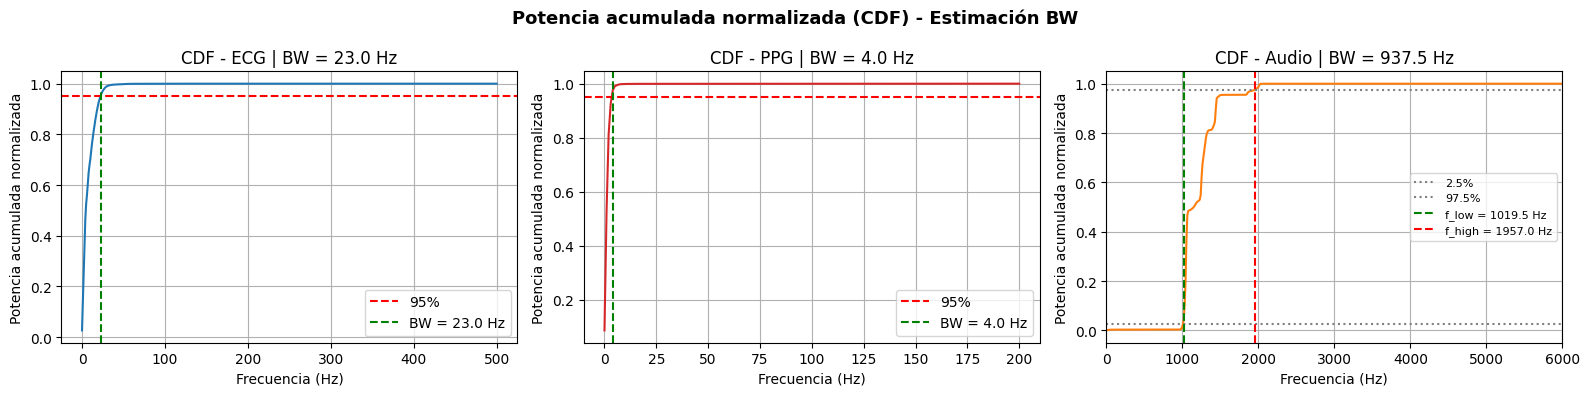

In [15]:

# ECG y PPG - pasabajas: acumula desde 0 hasta 95%
def calcular_bw_pasabajas(f, P, umbral=0.95):
    potencia_acumulada = np.cumsum(P) * (f[1] - f[0])
    potencia_total = potencia_acumulada[-1]
    cdf = potencia_acumulada / potencia_total
    idx = np.searchsorted(cdf, umbral)
    f_bw = f[idx]
    return f_bw, cdf

# Audio - pasabanda: 2.5% en cada extremo
def calcular_bw_pasabanda(f, P, umbral=0.95):
    potencia_acumulada = np.cumsum(P) * (f[1] - f[0])
    potencia_total = potencia_acumulada[-1]
    cdf = potencia_acumulada / potencia_total
    margen = (1 - umbral) / 2  # 0.025
    idx_low  = np.searchsorted(cdf, margen)
    idx_high = np.searchsorted(cdf, 1 - margen)
    f_low  = f[idx_low]
    f_high = f[idx_high]
    bw     = f_high - f_low
    return f_low, f_high, bw, cdf

# Calcular
bw_ecg, cdf_ecg                        = calcular_bw_pasabajas(f_ECG,   P_ECG)
bw_ppg, cdf_ppg                        = calcular_bw_pasabajas(f_PPG,   P_PPG)
f_low_audio, f_high_audio, bw_audio, cdf_audio = calcular_bw_pasabanda(f_audio, P_audio)

# =====================================================================
# --- TABLA ---
# =====================================================================
print("\n" + "="*65)
print(f"{'Señal':<10} {'f_low (Hz)':>12} {'f_high (Hz)':>12} {'BW (Hz)':>12}")
print("="*65)
print(f"{'ECG':<10} {'0.00':>12} {bw_ecg:>12.2f} {bw_ecg:>12.2f}")
print(f"{'PPG':<10} {'0.00':>12} {bw_ppg:>12.2f} {bw_ppg:>12.2f}")
print(f"{'Audio':<10} {f_low_audio:>12.2f} {f_high_audio:>12.2f} {bw_audio:>12.2f}")
print("="*65)

# =====================================================================
# --- GRAFICOS CDF ---
# =====================================================================
fig4, axes4 = plt.subplots(1, 3, figsize=(16, 4))

# ECG
axes4[0].plot(f_ECG, cdf_ecg, color='tab:blue')
axes4[0].axhline(0.95, color='red', linestyle='--', label='95%')
axes4[0].axvline(bw_ecg, color='green', linestyle='--', label=f'BW = {bw_ecg:.1f} Hz')
axes4[0].set_title(f'CDF - ECG | BW = {bw_ecg:.1f} Hz')
axes4[0].set_xlabel('Frecuencia (Hz)')
axes4[0].set_ylabel('Potencia acumulada normalizada')
axes4[0].legend()
axes4[0].grid(True)

# PPG
axes4[1].plot(f_PPG, cdf_ppg, color='tab:red')
axes4[1].axhline(0.95, color='red', linestyle='--', label='95%')
axes4[1].axvline(bw_ppg, color='green', linestyle='--', label=f'BW = {bw_ppg:.1f} Hz')
axes4[1].set_title(f'CDF - PPG | BW = {bw_ppg:.1f} Hz')
axes4[1].set_xlabel('Frecuencia (Hz)')
axes4[1].set_ylabel('Potencia acumulada normalizada')
axes4[1].legend()
axes4[1].grid(True)

# Audio - pasabanda con dos líneas
axes4[2].plot(f_audio, cdf_audio, color='tab:orange')
axes4[2].axhline(0.025, color='gray',  linestyle=':',  label='2.5%')
axes4[2].axhline(0.975, color='gray',  linestyle=':',  label='97.5%')
axes4[2].axvline(f_low_audio,  color='green', linestyle='--', label=f'f_low = {f_low_audio:.1f} Hz')
axes4[2].axvline(f_high_audio, color='red',   linestyle='--', label=f'f_high = {f_high_audio:.1f} Hz')
axes4[2].set_title(f'CDF - Audio | BW = {bw_audio:.1f} Hz')
axes4[2].set_xlabel('Frecuencia (Hz)')
axes4[2].set_ylabel('Potencia acumulada normalizada')
axes4[2].set_xlim(0, 6000)
axes4[2].legend(fontsize=8)
axes4[2].grid(True)

fig4.suptitle('Potencia acumulada normalizada (CDF) - Estimación BW', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Como se observa en los resultados, los anchos de banda del ECG (23 Hz) y del PPG (4 Hz) se concentran en las bajas frecuencias, lo que evidencia su comportamiento de tipo pasabajos. En cambio, para el caso del audio, el ancho de banda de 937.5 Hz se localiza estrictamente en una banda central (entre 1019.5 Hz y 1957 Hz), lo que demuestra un comportamiento claramente pasabanda

### Bonus - Análisis de Silbido mio

Para este caso, la señal elegida es un silbido grabado utilizando la aplicación " Grabadora Nativa" de un smartphone con un sistema operativo Android 15. La grabacion fue realizada en un ambiente cerrrado con bajo nivel de ruido ambiente. La digitalización fue llevada a cabo por el conversor analógico-digital (ADC) integrado en el micrófono del dispositivo.

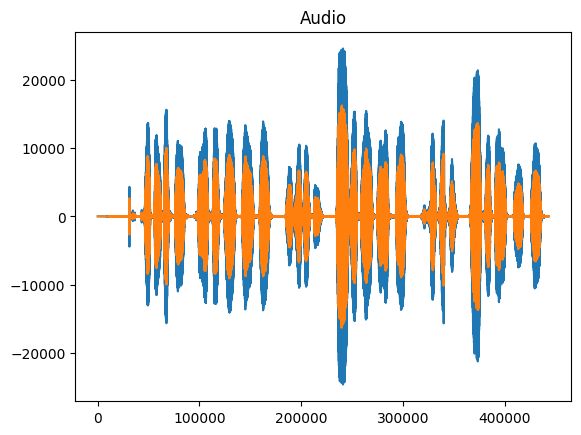

In [16]:
###########
##BONUS####
###########

fs_audio_mio, wav_data_mio = sio.wavfile.read('pdstestbench\silbido-_yo.wav')


plt.figure()
plt.title('Audio')
plt.plot(wav_data_mio)

Grafico su PSD con el teorema de Welch en escala lineal y logaritmica. También, calculo su ancho de banda.

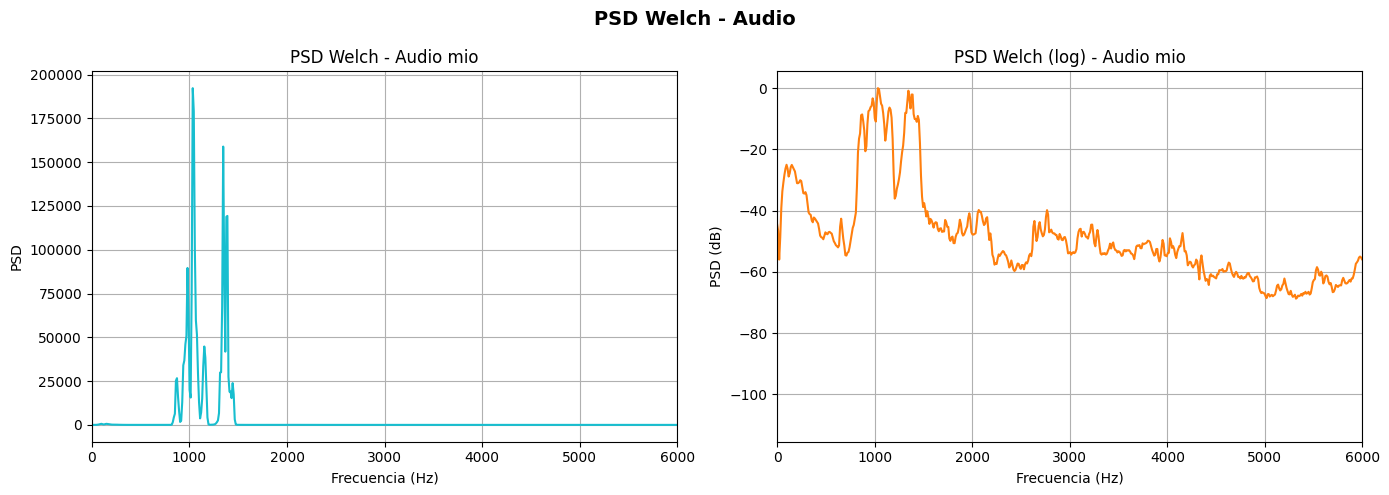


Señal        f_low (Hz)  f_high (Hz)      BW (Hz)
Silbido          872.09      1431.96       559.86


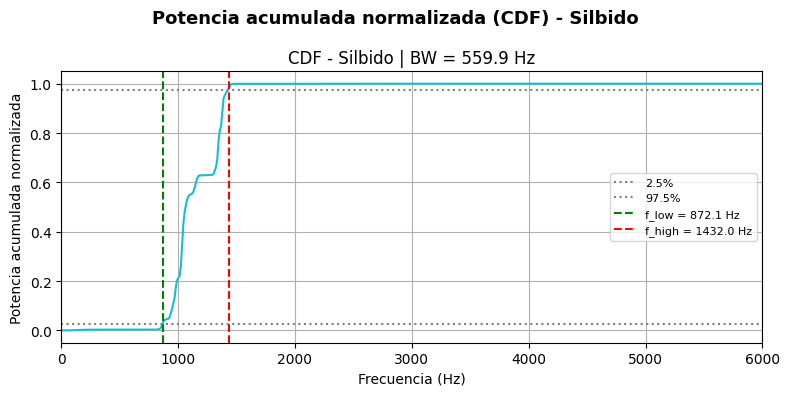

In [17]:

if len(wav_data_mio.shape) > 1:
    audio_procesar_mio = wav_data_mio[:, 0]
else:
    audio_procesar_mio = wav_data_mio

nperseg = 4096
noverlap = nperseg // 2

#WELCH

f_audio_mio, P_audio_mio = sig.welch(audio_procesar_mio, fs_audio_mio, window='hann', nperseg=nperseg, noverlap=noverlap)

# =====================================================================
# --- FIGURA 4: AUDIO MIO - Lineal y Logarítmica ---
# =====================================================================
fig5, axes5 = plt.subplots(1, 2, figsize=(14, 5))

# Lineal
axes5[0].plot(f_audio_mio, P_audio_mio, color='tab:cyan')
axes5[0].set_title('PSD Welch - Audio mio')
axes5[0].set_xlabel('Frecuencia (Hz)')
axes5[0].set_ylabel('PSD')
axes5[0].set_xlim(0, 6000)
axes5[0].grid(True)

# Logarítmica
axes5[1].plot(f_audio_mio, 10*np.log10(P_audio_mio / P_audio_mio.max()), color='tab:orange')
axes5[1].set_title('PSD Welch (log) - Audio mio')
axes5[1].set_xlabel('Frecuencia (Hz)')
axes5[1].set_ylabel('PSD (dB)')
axes5[1].set_xlim(0, 6000)
axes5[1].grid(True)

fig5.suptitle('PSD Welch - Audio', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Ancho de banda - pasabanda (2.5% inicio, 95% util, 2.5% final)
f_low_mio, f_high_mio, bw_mio, cdf_mio = calcular_bw_pasabanda(f_audio_mio, P_audio_mio)

# Tabla
print("\n" + "="*65)
print(f"{'Señal':<10} {'f_low (Hz)':>12} {'f_high (Hz)':>12} {'BW (Hz)':>12}")
print("="*65)
print(f"{'Silbido':<10} {f_low_mio:>12.2f} {f_high_mio:>12.2f} {bw_mio:>12.2f}")
print("="*65)

# CDF
fig6, ax6 = plt.subplots(1, 1, figsize=(8, 4))
ax6.plot(f_audio_mio, cdf_mio, color='tab:cyan')
ax6.axhline(0.025, color='gray',  linestyle=':',  label='2.5%')
ax6.axhline(0.975, color='gray',  linestyle=':',  label='97.5%')
ax6.axvline(f_low_mio,  color='green', linestyle='--', label=f'f_low = {f_low_mio:.1f} Hz')
ax6.axvline(f_high_mio, color='red',   linestyle='--', label=f'f_high = {f_high_mio:.1f} Hz')
ax6.set_title(f'CDF - Silbido | BW = {bw_mio:.1f} Hz')
ax6.set_xlabel('Frecuencia (Hz)')
ax6.set_ylabel('Potencia acumulada normalizada')
ax6.set_xlim(0, 6000)
ax6.legend(fontsize=8)
ax6.grid(True)
fig6.suptitle('Potencia acumulada normalizada (CDF) - Silbido', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Finalmente vemos, como en el caso del audio anterior, que el comportamiento es de un pasabanda, donde la señal util se encuentra entre los valores de 872 Hz y 1431 Hz.